# Baseline Model

Test simple rolling-average baselines for predicting the next trading day's SPY return.

## Code Steps

1. Load the processed feature dataset from `data/processed/starter_returns_dataset.csv`.
2. Use `SPY_ret_1d` as the historical return series.
3. Create simple predictions:
   - `pred_zero`: always predict 0.
   - `pred_momentum_5d`: predict the average SPY return from the last 5 trading days.
   - `pred_momentum_10d`: predict the average SPY return from the last 10 trading days.
   - `pred_momentum_20d`: predict the average SPY return from the last 20 trading days.
   - `pred_reversion_*`: use the negative of those rolling averages.
4. Compare each prediction against `spy_next_day_return`.
5. Score each baseline mostly like a trading strategy: Sharpe ratio, total return, annual return, volatility, max drawdown, and directional accuracy.
6. Keep MAE and RMSE as secondary diagnostics, not the main decision metrics.
7. Save the baseline predictions and results for later comparison with real ML models.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "starter_returns_dataset.csv"
PREDICTIONS_PATH = PROJECT_ROOT / "data" / "processed" / "baseline_predictions.csv"
RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "baseline_results.csv"

In [2]:
# Step 1: load the modeling dataset created in notebook 01.
dataset = pd.read_csv(DATASET_PATH, parse_dates=["Date"])
dataset = dataset.sort_values("Date").reset_index(drop=True)

target_col = "spy_next_day_return"
dataset[["Date", "SPY_ret_1d", target_col]].head()

,Date,SPY_ret_1d,spy_next_day_return
0,2015-10-16,0.004546,0.000492
1,2015-10-19,0.000492,-0.001279
2,2015-10-20,-0.001279,-0.006203
3,2015-10-21,-0.006203,0.016894
4,2015-10-22,0.016894,0.010962


In [3]:
# Steps 2 and 3: build simple rolling-average baseline predictions.
baseline = dataset[["Date", "SPY_ret_1d", target_col]].copy()

# Predict no movement tomorrow.
baseline["pred_zero"] = 0.0

# Predict tomorrow's return as the average of recent SPY returns.
# The reversion versions assume tomorrow moves opposite recent momentum.
for window in [5, 10, 20]:
    rolling_mean = baseline["SPY_ret_1d"].rolling(window).mean()
    baseline[f"pred_momentum_{window}d"] = rolling_mean
    baseline[f"pred_reversion_{window}d"] = -rolling_mean

prediction_cols = [col for col in baseline.columns if col.startswith("pred_")]

# Drop the warmup rows where 20-day rolling averages are not available yet.
baseline_eval = baseline.dropna(subset=prediction_cols + [target_col]).copy()
baseline_eval.head()

,Date,SPY_ret_1d,spy_next_day_return,pred_zero,pred_momentum_5d,pred_reversion_5d,pred_momentum_10d,pred_reversion_10d,pred_momentum_20d,pred_reversion_20d
19,2015-11-12,-0.013960,-0.011228,0.0,-0.005088,0.005088,-0.001905,0.001905,0.000639,-0.000639
20,2015-11-13,-0.011228,0.015207,0.0,-0.007229,0.007229,-0.002597,0.002597,-0.000150,0.000150
21,2015-11-16,0.015207,-0.000729,0.0,-0.002321,0.002321,-0.002259,0.002259,0.000586,-0.000586
22,2015-11-17,-0.000729,0.015866,0.0,-0.002928,0.002928,-0.002622,0.002622,0.000613,-0.000613
23,2015-11-18,0.015866,-0.000863,0.0,0.001031,-0.001031,-0.000732,0.000732,0.001717,-0.001717


In [4]:
# Steps 4, 5, and 6: evaluate each baseline.
def max_drawdown(returns: pd.Series) -> float:
    equity_curve = (1 + returns).cumprod()
    running_high = equity_curve.cummax()
    drawdown = equity_curve / running_high - 1
    return drawdown.min()


def evaluate_predictions(frame: pd.DataFrame, prediction_col: str) -> dict[str, float | str]:
    actual = frame[target_col]
    pred = frame[prediction_col]
    error = pred - actual

    predicted_up = pred > 0
    actual_up = actual > 0
    direction_accuracy = (predicted_up == actual_up).mean()

    # Simple trading interpretation: long SPY when prediction is positive, otherwise stay in cash.
    position = predicted_up.astype(float)
    strategy_returns = position * actual
    buy_hold_returns = actual

    trading_days = 252
    strategy_total_return = (1 + strategy_returns).prod() - 1
    buy_hold_total_return = (1 + buy_hold_returns).prod() - 1
    years = len(frame) / trading_days

    strategy_annual_return = (1 + strategy_total_return) ** (1 / years) - 1
    buy_hold_annual_return = (1 + buy_hold_total_return) ** (1 / years) - 1
    strategy_annual_volatility = strategy_returns.std(ddof=0) * np.sqrt(trading_days)
    buy_hold_annual_volatility = buy_hold_returns.std(ddof=0) * np.sqrt(trading_days)
    strategy_max_drawdown = max_drawdown(strategy_returns)
    buy_hold_max_drawdown = max_drawdown(buy_hold_returns)

    strategy_std = strategy_returns.std(ddof=0)
    strategy_sharpe = np.nan if strategy_std == 0 else strategy_returns.mean() / strategy_std * np.sqrt(252)
    buy_hold_std = buy_hold_returns.std(ddof=0)
    buy_hold_sharpe = np.nan if buy_hold_std == 0 else buy_hold_returns.mean() / buy_hold_std * np.sqrt(252)
    strategy_calmar = np.nan if strategy_max_drawdown == 0 else strategy_annual_return / abs(strategy_max_drawdown)

    return {
        "model": prediction_col,
        "rows": len(frame),
        "strategy_sharpe": strategy_sharpe,
        "strategy_total_return": strategy_total_return,
        "strategy_annual_return": strategy_annual_return,
        "strategy_annual_volatility": strategy_annual_volatility,
        "strategy_max_drawdown": strategy_max_drawdown,
        "strategy_calmar": strategy_calmar,
        "directional_accuracy": direction_accuracy,
        "exposure": position.mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error**2).mean()),
        "avg_prediction": pred.mean(),
        "buy_hold_sharpe": buy_hold_sharpe,
        "buy_hold_total_return": buy_hold_total_return,
        "buy_hold_annual_return": buy_hold_annual_return,
        "buy_hold_annual_volatility": buy_hold_annual_volatility,
        "buy_hold_max_drawdown": buy_hold_max_drawdown,
    }


results = pd.DataFrame(
    evaluate_predictions(baseline_eval, col) for col in prediction_cols
).sort_values("strategy_sharpe", ascending=False, na_position="last")

results

,model,rows,strategy_sharpe,strategy_total_return,strategy_annual_return,strategy_annual_volatility,strategy_max_drawdown,strategy_calmar,directional_accuracy,exposure,mae,rmse,avg_prediction,buy_hold_sharpe,buy_hold_total_return,buy_hold_annual_return,buy_hold_annual_volatility,buy_hold_max_drawdown
3,pred_momentum_10d,2668,1.088561,2.178986,0.115431,0.105490,-0.124708,0.925606,0.517241,0.662294,0.007674,0.011773,0.000603,0.85589,3.246453,0.146354,0.178239,-0.337173
5,pred_momentum_20d,2668,1.048065,2.083456,0.112221,0.106974,-0.155597,0.721228,0.526612,0.701649,0.007469,0.011517,0.000608,0.85589,3.246453,0.146354,0.178239,-0.337173
2,pred_reversion_5d,2668,0.662576,1.418821,0.087007,0.140941,-0.274621,0.316826,0.504498,0.378186,0.008038,0.011971,-0.000603,0.85589,3.246453,0.146354,0.178239,-0.337173
1,pred_momentum_5d,2668,0.541295,0.755588,0.054597,0.109309,-0.147549,0.370023,0.495502,0.621814,0.008098,0.012339,0.000603,0.85589,3.246453,0.146354,0.178239,-0.337173
6,pred_reversion_20d,2668,0.283383,0.377173,0.030689,0.142694,-0.321046,0.095592,0.473388,0.298351,0.007613,0.011432,-0.000608,0.85589,3.246453,0.146354,0.178239,-0.337173
4,pred_reversion_10d,2668,0.262335,0.335789,0.027723,0.143789,-0.337767,0.082079,0.482759,0.337706,0.007767,0.011616,-0.000603,0.85589,3.246453,0.146354,0.178239,-0.337173
0,pred_zero,2668,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.447151,0.000000,0.007317,0.011244,0.000000,0.85589,3.246453,0.146354,0.178239,-0.337173


In [5]:
# More readable formatting for notebook viewing, focused on trading metrics first.
display_results = results.copy()
percent_cols = [
    "strategy_total_return",
    "strategy_annual_return",
    "strategy_annual_volatility",
    "strategy_max_drawdown",
    "strategy_calmar",
    "directional_accuracy",
    "exposure",
    "mae",
    "rmse",
    "avg_prediction",
    "buy_hold_total_return",
    "buy_hold_annual_return",
    "buy_hold_annual_volatility",
    "buy_hold_max_drawdown",
]

for col in percent_cols:
    display_results[col] = display_results[col].map(lambda value: f"{value:.2%}")

display_results[[
    "model",
    "strategy_sharpe",
    "strategy_total_return",
    "strategy_annual_return",
    "strategy_annual_volatility",
    "strategy_max_drawdown",
    "strategy_calmar",
    "directional_accuracy",
    "exposure",
    "mae",
    "rmse",
    "buy_hold_sharpe",
    "buy_hold_total_return",
]]

,model,strategy_sharpe,strategy_total_return,strategy_annual_return,strategy_annual_volatility,strategy_max_drawdown,strategy_calmar,directional_accuracy,exposure,mae,rmse,buy_hold_sharpe,buy_hold_total_return
3,pred_momentum_10d,1.088561,217.90%,11.54%,10.55%,-12.47%,92.56%,51.72%,66.23%,0.77%,1.18%,0.85589,324.65%
5,pred_momentum_20d,1.048065,208.35%,11.22%,10.70%,-15.56%,72.12%,52.66%,70.16%,0.75%,1.15%,0.85589,324.65%
2,pred_reversion_5d,0.662576,141.88%,8.70%,14.09%,-27.46%,31.68%,50.45%,37.82%,0.80%,1.20%,0.85589,324.65%
1,pred_momentum_5d,0.541295,75.56%,5.46%,10.93%,-14.75%,37.00%,49.55%,62.18%,0.81%,1.23%,0.85589,324.65%
6,pred_reversion_20d,0.283383,37.72%,3.07%,14.27%,-32.10%,9.56%,47.34%,29.84%,0.76%,1.14%,0.85589,324.65%
4,pred_reversion_10d,0.262335,33.58%,2.77%,14.38%,-33.78%,8.21%,48.28%,33.77%,0.78%,1.16%,0.85589,324.65%
0,pred_zero,NaN,0.00%,0.00%,0.00%,0.00%,nan%,44.72%,0.00%,0.73%,1.12%,0.85589,324.65%


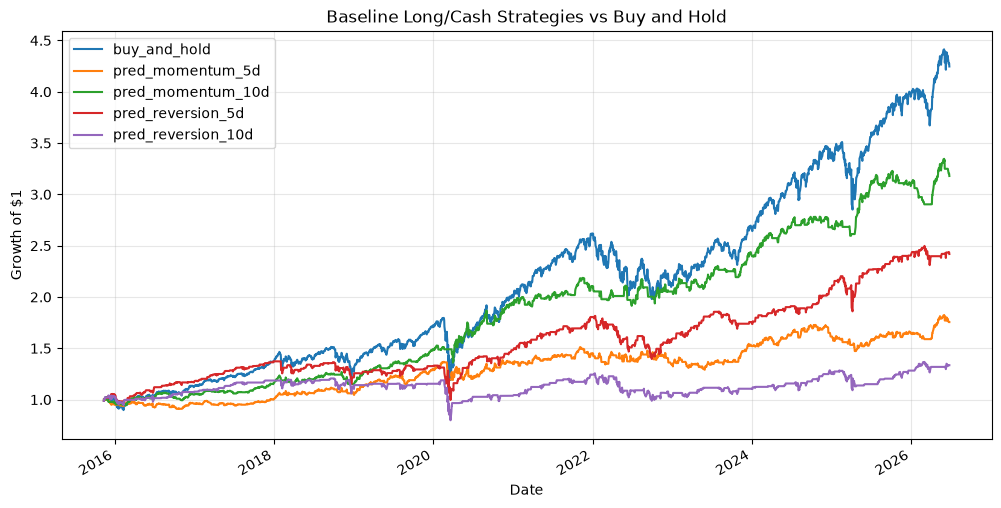

In [6]:
# Visual check: compare cumulative returns for the baseline trading rules.
plot_frame = baseline_eval[["Date", target_col]].copy()
plot_frame["buy_and_hold"] = (1 + plot_frame[target_col]).cumprod()

for col in ["pred_momentum_5d", "pred_momentum_10d", "pred_reversion_5d", "pred_reversion_10d"]:
    strategy_returns = (baseline_eval[col] > 0).astype(float) * baseline_eval[target_col]
    plot_frame[col] = (1 + strategy_returns).cumprod()

ax = plot_frame.set_index("Date").drop(columns=[target_col]).plot(figsize=(12, 6))
ax.set_title("Baseline Long/Cash Strategies vs Buy and Hold")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

In [7]:
# Extra check: performance by year helps reveal whether a baseline only worked in certain regimes.
yearly_rows = []

for year, year_frame in baseline_eval.groupby(baseline_eval["Date"].dt.year):
    for col in prediction_cols:
        actual = year_frame[target_col]
        pred = year_frame[col]
        strategy_returns = (pred > 0).astype(float) * actual
        strategy_std = strategy_returns.std(ddof=0)
        yearly_rows.append(
            {
                "year": year,
                "model": col,
                "rows": len(year_frame),
                "strategy_sharpe": np.nan if strategy_std == 0 else strategy_returns.mean() / strategy_std * np.sqrt(252),
                "directional_accuracy": ((pred > 0) == (actual > 0)).mean(),
                "strategy_total_return": (1 + strategy_returns).prod() - 1,
                "strategy_max_drawdown": max_drawdown(strategy_returns),
                "buy_hold_total_return": (1 + actual).prod() - 1,
                "buy_hold_max_drawdown": max_drawdown(actual),
            }
        )

yearly_results = pd.DataFrame(yearly_rows)
yearly_results.head(10)

,year,model,rows,strategy_sharpe,directional_accuracy,strategy_total_return,strategy_max_drawdown,buy_hold_total_return,buy_hold_max_drawdown
0,2015,pred_zero,34,NaN,0.558824,0.000000,0.000000,-0.012808,-0.044948
1,2015,pred_momentum_5d,34,-4.237263,0.382353,-0.049967,-0.053914,-0.012808,-0.044948
2,2015,pred_reversion_5d,34,2.187252,0.617647,0.039114,-0.017815,-0.012808,-0.044948
3,2015,pred_momentum_10d,34,-3.412826,0.411765,-0.032709,-0.040101,-0.012808,-0.044948
4,2015,pred_reversion_10d,34,1.106874,0.588235,0.020574,-0.034267,-0.012808,-0.044948
5,2015,pred_momentum_20d,34,-0.754622,0.470588,-0.009222,-0.022218,-0.012808,-0.044948
6,2015,pred_reversion_20d,34,-0.123654,0.529412,-0.003620,-0.036924,-0.012808,-0.044948
7,2016,pred_zero,252,NaN,0.452381,0.000000,0.000000,0.144547,-0.091875
8,2016,pred_momentum_5d,252,0.170928,0.476190,0.011243,-0.070659,0.144547,-0.091875
9,2016,pred_reversion_5d,252,1.349925,0.523810,0.131822,-0.081003,0.144547,-0.091875


In [8]:
# Step 6: save outputs so later ML notebooks can compare against the same baselines.
baseline_eval.to_csv(PREDICTIONS_PATH, index=False)
results.to_csv(RESULTS_PATH, index=False)

PREDICTIONS_PATH, RESULTS_PATH

(WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/baseline_predictions.csv'),
 WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/baseline_results.csv'))